## 1. Bit-Flipping Fault Injection Attack on AES

The **bit-flipping fault injection attack** is a form of differential fault analysis (DFA) applied to the Advanced Encryption Standard (AES).
It involves intentionally flipping a single bit in the internal AES state and observing the resulting difference in the output ciphertext.
This method leverages the structure of AES, particularly the **absence of the MixColumns operation in the final round**.

By targeting the output of the **9th round** in AES-128 (which consists of 10 total rounds), a fault in one bit of the state affects only **one byte** in the final ciphertext.
This localized effect makes the fault easier to analyze and allows the attacker to recover the **last round key** one byte at a time,
thereby reducing the key search space significantly.

> **Note:** Recovering a single byte of the round key typically requires **multiple bit-flipping faults** to be injected and analyzed.
These differential traces help narrow down the correct intermediate value and eliminate incorrect key candidates.

### Attack Principle

Let:

- `s` be the 9th round output (fault-free)  
- `s'` be the 9th round output after a single-bit fault  
- `C` be the correct ciphertext  
- `C'` be the faulty ciphertext  
- `K` be the last round key  
- `round()` represent the final AES round (`SubBytes → ShiftRows`)

The encryption equations are:

```
C  = round(s)  ⊕ K  
C' = round(s') ⊕ K
```

Taking the XOR of the correct and faulty ciphertexts:

```
C ⊕ C' = round(s) ⊕ round(s')
```

This differential depends only on the transformation between `s` and `s'` through the final round.
By analyzing this difference, the attacker can reverse-engineer the fault-free intermediate state `s`.


### Key Recovery

Once the intermediate state `s` is known, the final round key can be derived as:

```
K = round(s) ⊕ C
```

By repeating this process for all 16 bytes (possibly requiring multiple faults per byte),
the attacker can reconstruct the entire last round key.
From there, the original AES key can be recovered using the inverse key schedule.


Below figure is a visual representation of the above attack.

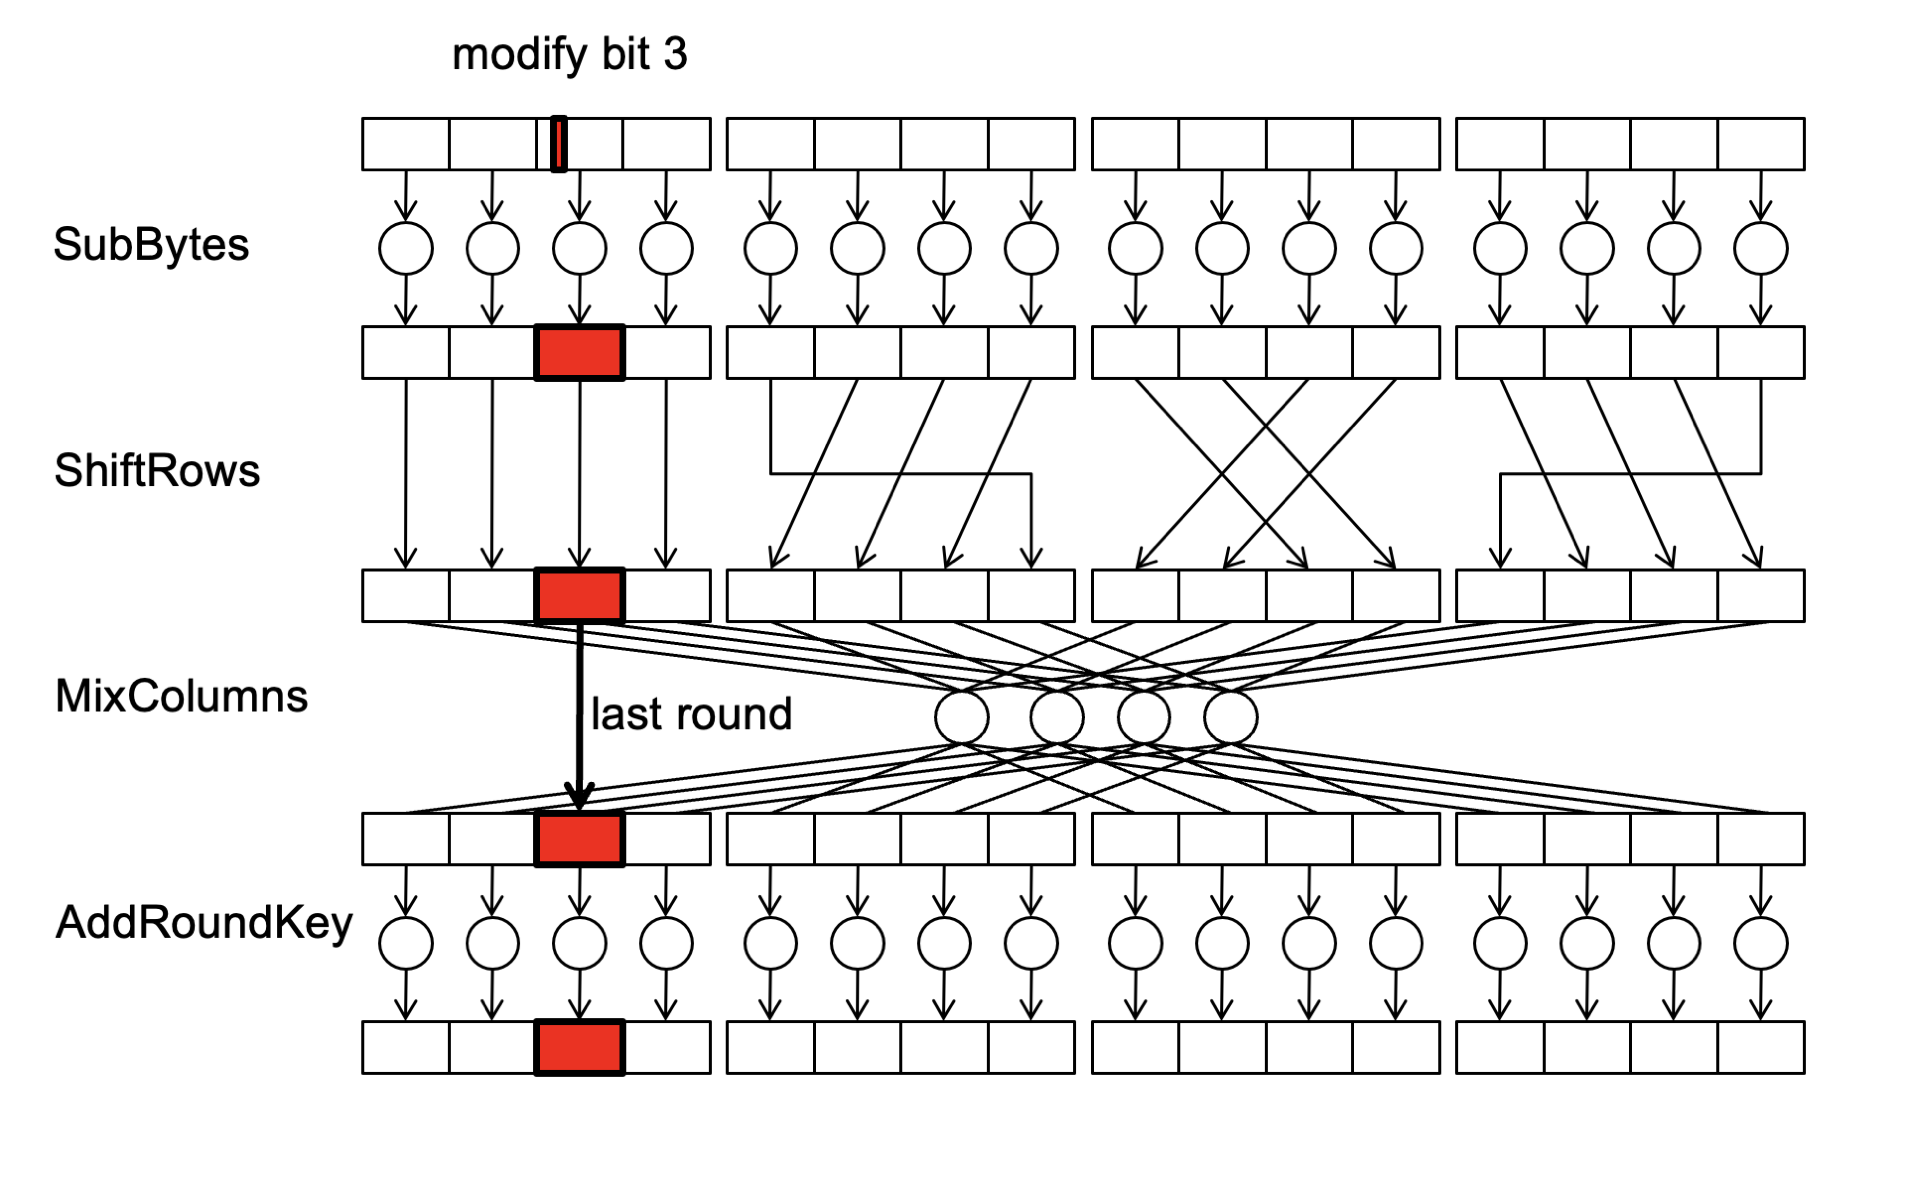

## 2. 3-bit S-box example

* Consider the following S-Box, where XYZ corresponds to the input 3-bits in
little-endian format, and out is the output.


| XYZ | 000 | 001 | 010 | 011 | 100 | 101 | 110 | 111 |
|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| out | 010 | 100 | 101 | 000 | 111 | 110 | 001 | 010 |

* Take an example where you are flipping the MSB to peform your fault injection.

* Evaluate the following expression for all possible input combinations (s) and its bit-flipped input (s')

```
s ⊕ s'
```

* Do you see any patterns in the table for ```s ⊕ s'```?

* If you observe that the value of ```s ⊕ s'``` was observed to be 100, how many possible inputs match this case when the MSB is your attack point?

* How would you narrow this down to a single ```s```?

* Assume you perform the attack on the center bit and your observe ```s ⊕ s'``` to be 111, what is the value of ```s```.


## 2. Get files from Drive

This steps imports the required RTL files for AES and its testbench into our environment.

In [ ]:
!pip install gdown

In [ ]:
# The folder is (https://drive.google.com/drive/folders/1lYUy_kd3ZDV5WRKKEjjuGVvKnCKKz6IC)

import gdown

gdown.download_folder(id='1lYUy_kd3ZDV5WRKKEjjuGVvKnCKKz6IC', quiet=False, use_cookies=False)

Retrieving folder contents


Retrieving folder 111-DNEcNPpvZAOKUEWY0FiO_mQyzjml6 rtl
Processing file 13dWpfVvOac_d0zNfr9mwprLf6I7VeFng aes128_table_ecb.sv
Retrieving folder 1qHU7NFkgb_VnMMZRLbbdsYHZ6yUxz9OM sim
Processing file 1OylT_1Qo4VVcvd_-Tvx0gtjnDxjwjIAr state_xor_input.txt
Processing file 1lAkQU4-RqID7GZmSxUsKMru7RdVydvv2 tb_aes128_table_ecb.sv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=13dWpfVvOac_d0zNfr9mwprLf6I7VeFng
To: /content/FIA_AES/rtl/aes128_table_ecb.sv
100%|██████████| 41.3k/41.3k [00:00<00:00, 16.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1OylT_1Qo4VVcvd_-Tvx0gtjnDxjwjIAr
To: /content/FIA_AES/sim/state_xor_input.txt
100%|██████████| 32.0/32.0 [00:00<00:00, 55.7kB/s]
Downloading...
From: https://drive.google.com/uc?id=1lAkQU4-RqID7GZmSxUsKMru7RdVydvv2
To: /content/FIA_AES/sim/tb_aes128_table_ecb.sv
100%|██████████| 8.16k/8.16k [00:00<00:00, 14.3MB/s]
Download completed


['/content/FIA_AES/rtl/aes128_table_ecb.sv',
 '/content/FIA_AES/sim/state_xor_input.txt',
 '/content/FIA_AES/sim/tb_aes128_table_ecb.sv']

## 2. Setup iVerilog simulation environment

This step sets up the iVerilog simulation environment.

Input Files

In [ ]:
RTL_File = "FIA_AES/rtl/aes128_table_ecb.sv"
SIM_File = "FIA_AES/sim/tb_aes128_table_ecb.sv"
CIPHERTEXT_File = "FIA_AES/ciphertext_output.txt"
# It is likely that the text file used in simulation need not be specified here.

Directory Structure:

```
> FIA_AES
  > rtl
  > sim
```

- ```FIA_AES``` is the parent folder, which contains 2 sub-folders.
  - ```rtl```
    - This subfolder contains the Verilog RTL model of AES-128 (```aes128_table_ecb.sv```).
    - This is modified to simulate FIA using a laser.
  - ```sim```
    - This subfolder contains the testbench for the AES-128 RTL (```tb_aes128_table_ecb.sv```).

### 2.1 Install iVerilog

In [ ]:
!apt update && apt install -y iverilog

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,918 kB]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [32.9 kB]
Fetched 2,358 kB in 2s (1,005 k

### 2.2 Simulation Commands

-o : output file,
-g : verilog version

In [ ]:
!iverilog -g2012 -o aes.out $RTL_File $SIM_File
!vvp aes.out > output.txt

FIA_AES/rtl/aes128_table_ecb.sv:706: warning: extra digits given for sized binary constant.
FIA_AES/rtl/aes128_table_ecb.sv:747: warning: extra digits given for sized binary constant.


## 3. Performing the fault injection attack in our simulation environment


* Select a 128-bit plaintext for your experiment. This can be inserted by calling the function `set_plaintext(SIM_File,128'hDCFEAD50D1D9FD08B386EFB08B142F74")`
* Initially, observe the output ciphertext without inserting any faults. This can be achieved by running the command shown in Step 2.2.
* Next step is to pick a bit to flip using fault injection on the output of the 9th round of AES. This can be performed by calling the fuction `insert_fault_mask(SIM_File, generate_verilog_mask(127))`, where the number represents the bit position to perform the fault ijection. Please note that the register is little-endian, where MSB is 127 and LSB is 0. Running the command with 128 will run AES with no fault injection, which is required to perform the initial observation. Do note that the above function sets the location of the fault injection attack. After setting the location, you need to run the simulation to observe the new ciphertext.
* Repeat this attack as many times as needed on a specific byte of the output of 9th round of AES to narrow down the key byte correspond to this.
* For your convenience, S-Box is defined below as `Substitution_Box`.



Use the code snippets in Section 3.1 to perform the attack. Start with the attack on the MSB bytes, as they are unaffected by ShiftRows operation.

After successfully retrieving the 9th round KEY, use it to recover the secret KEY by performing the inverse of AES key expansion.

### 3.1 Custom **Functions**

#### 3.1.1 Function to set plaintext

In [ ]:
def set_plaintext(sim_file_path, plaintext="128'hDCFEAD50D1D9FD08B386EFB08B142F74"):
    """
    Inserts a fault mask into a specific line of the given file.

    Parameters:
    - sim_file_path (str): Path to the file to modify.
    - line_number (int): Line number (1-based index) to modify. Defaults to 36.
    - plaintext (str): The plaintext string for AES. Defaults to a predefined 128-bit value.
    """
    line_number=66
    try:
        with open(sim_file_path, 'r') as f:
            lines = f.readlines()

        if line_number < 1 or line_number > len(lines):
            raise IndexError("Line number out of range.")

        lines[line_number - 1] = f"  reg [AES_SIZE:0] test_vectors_tb_sig = {plaintext};\n"

        with open(sim_file_path, 'w') as f:
            f.writelines(lines)

    except Exception as e:
        print(f"An error occurred: {e}")

#### 3.1.2 Function to insert the generated fault mask in the testbench (as this is a simulation of fault injection attack)

In [ ]:
def insert_fault_mask(sim_file_path, fault_mask="128'h00000000000000000000000000000000"):
    """
    Inserts a fault mask into a specific line of the given file.

    Parameters:
    - sim_file_path (str): Path to the file to modify.
    - line_number (int): Line number (1-based index) to modify. Defaults to 36.
    - fault_mask (str): The fault mask string to insert. Defaults to a predefined 128-bit value.
    """
    line_number=36
    try:
        with open(sim_file_path, 'r') as f:
            lines = f.readlines()

        if line_number < 1 or line_number > len(lines):
            raise IndexError("Line number out of range.")

        lines[line_number - 1] = f"  localparam STATE_XOR = {fault_mask};\n"

        with open(sim_file_path, 'w') as f:
            f.writelines(lines)

    except Exception as e:
        print(f"An error occurred: {e}")


#### 3.1.3 Function to generate the fault mask (bit mask of where the fault occurs)

In [ ]:
def generate_verilog_mask(bit_position):
    """
    Generates a Verilog 128-bit mask in little-endian format with a '1' at the specified bit position.

    Parameters:
    - bit_position (int): Bit position to set (0 to 127). If 128, output is all zeros.

    Returns:
    - str: Verilog-style little-endian hexadecimal string, e.g., "128'h00000000000000000000000000000080"
    """
    if bit_position == 128:
        return "128'h00000000000000000000000000000000"
    if not (0 <= bit_position < 128):
        raise ValueError("bit_position must be between 0 and 128 inclusive.")

    value = 1 << bit_position  # NOTE: For little-endian, no reversal of bit position
    hex_value = f"{value:032x}"  # 128 bits = 32 hex digits
    return f"128'h{hex_value.upper()}"


#### 3.1.4 S-Box


In [ ]:
Substitution_Box = [0 for i in range(16)]

In [ ]:
Substitution_Box[0] = [0x63, 0x7c, 0x77, 0x7b, 0xf2, 0x6b, 0x6f, 0xc5, 0x30, 0x01, 0x67, 0x2b, 0xfe, 0xd7, 0xab, 0x76]
Substitution_Box[1] = [0xca, 0x82, 0xc9, 0x7d, 0xfa, 0x59, 0x47, 0xf0, 0xad, 0xd4, 0xa2, 0xaf, 0x9c, 0xa4, 0x72, 0xc0]
Substitution_Box[2] = [0xb7, 0xfd, 0x93, 0x26, 0x36, 0x3f, 0xf7, 0xcc, 0x34, 0xa5, 0xe5, 0xf1, 0x71, 0xd8, 0x31, 0x15]
Substitution_Box[3] = [0x04, 0xc7, 0x23, 0xc3, 0x18, 0x96, 0x05, 0x9a, 0x07, 0x12, 0x80, 0xe2, 0xeb, 0x27, 0xb2, 0x75]
Substitution_Box[4] = [0x09, 0x83, 0x2c, 0x1a, 0x1b, 0x6e, 0x5a, 0xa0, 0x52, 0x3b, 0xd6, 0xb3, 0x29, 0xe3, 0x2f, 0x84]
Substitution_Box[5] = [0x53, 0xd1, 0x00, 0xed, 0x20, 0xfc, 0xb1, 0x5b, 0x6a, 0xcb, 0xbe, 0x39, 0x4a, 0x4c, 0x58, 0xcf]
Substitution_Box[6] = [0xd0, 0xef, 0xaa, 0xfb, 0x43, 0x4d, 0x33, 0x85, 0x45, 0xf9, 0x02, 0x7f, 0x50, 0x3c, 0x9f, 0xa8]
Substitution_Box[7] = [0x51, 0xa3, 0x40, 0x8f, 0x92, 0x9d, 0x38, 0xf5, 0xbc, 0xb6, 0xda, 0x21, 0x10, 0xff, 0xf3, 0xd2]
Substitution_Box[8] = [0xcd, 0x0c, 0x13, 0xec, 0x5f, 0x97, 0x44, 0x17, 0xc4, 0xa7, 0x7e, 0x3d, 0x64, 0x5d, 0x19, 0x73]
Substitution_Box[9] = [0x60, 0x81, 0x4f, 0xdc, 0x22, 0x2a, 0x90, 0x88, 0x46, 0xee, 0xb8, 0x14, 0xde, 0x5e, 0x0b, 0xdb]
Substitution_Box[0xa] = [0xe0, 0x32, 0x3a, 0x0a, 0x49, 0x06, 0x24, 0x5c, 0xc2, 0xd3, 0xac, 0x62, 0x91, 0x95, 0xe4, 0x79]
Substitution_Box[0xb] = [0xe7, 0xc8, 0x37, 0x6d, 0x8d, 0xd5, 0x4e, 0xa9, 0x6c, 0x56, 0xf4, 0xea, 0x65, 0x7a, 0xae, 0x08]
Substitution_Box[0xc] = [0xba, 0x78, 0x25, 0x2e, 0x1c, 0xa6, 0xb4, 0xc6, 0xe8, 0xdd, 0x74, 0x1f, 0x4b, 0xbd, 0x8b, 0x8a]
Substitution_Box[0xd] = [0x70, 0x3e, 0xb5, 0x66, 0x48, 0x03, 0xf6, 0x0e, 0x61, 0x35, 0x57, 0xb9, 0x86, 0xc1, 0x1d, 0x9e]
Substitution_Box[0xe] = [0xe1, 0xf8, 0x98, 0x11, 0x69, 0xd9, 0x8e, 0x94, 0x9b, 0x1e, 0x87, 0xe9, 0xce, 0x55, 0x28, 0xdf]
Substitution_Box[0xf] = [0x8c, 0xa1, 0x89, 0x0d, 0xbf, 0xe6, 0x42, 0x68, 0x41, 0x99, 0x2d, 0x0f, 0xb0, 0x54, 0xbb, 0x16]

### 3.2 Code Snippets

#### 3.2.1 Choose Bit Index to insert fault

In [ ]:
insert_fault_mask(SIM_File, generate_verilog_mask(127))

#### 3.2.2 Set Plaintext to chosen value (keep this fixed across all your fault injection runs)

In [ ]:
set_plaintext(SIM_File,"128'h00000000000000000000000000000000")

#### 3.2.3 Run Fault Injected Simulation

In [ ]:
!iverilog -g2012 -o aes.out $RTL_File $SIM_File
!vvp aes.out > faulty_output.txt

FIA_AES/rtl/aes128_table_ecb.sv:706: warning: extra digits given for sized binary constant.
FIA_AES/rtl/aes128_table_ecb.sv:747: warning: extra digits given for sized binary constant.


#### 3.2.4 Observe the output ciphertext

In [ ]:
with open("ciphertext_output.txt", "r") as f:
    ciphertext = f.read()
print(ciphertext)

85a13b37878f5b826f4f8162a1c8d879



#### 3.2.5 Fault injection attack code snippet

Use the below code snippet to perform the fault injection attack for a specific byte. Note, fault injection is not being performed below, we're providing the same input plaintext 9 times without performing any fault injection. Insert your fault injection code in the space provided in the snippet.

In [ ]:
import subprocess

ciphertext = ["" for i in range(9)]

for i in range(9):
    # Perform Fault injection here

    # Compile Verilog sources
    subprocess.run(["iverilog", "-g2012", "-o", "aes.out", RTL_File, SIM_File], check=True)

    # Run simulation and save output
    with open(f"faulty_output_{i}.txt", "w") as f:
        subprocess.run(["vvp", "aes.out"], stdout=f, check=True)

    with open("ciphertext_output.txt", "r") as f:
        ciphertext[i] = f.read()
